In [2]:
from src.data import *
from src.debug import print_dataset_info
from src.features import *
from src.models import *
from src.models import _flatten

import collections
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn import feature_extraction, model_selection
from sklearn.metrics import mean_squared_error, roc_auc_score, balanced_accuracy_score
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.preprocessing import MinMaxScaler


In [3]:
# Pipeline configuration
from src.config import MASK_VALUE

# Topic-tree surgery (see §3 for rationale).
TOPICS_TO_REPARENT = [2026, 2027, 2028]
REPARENT_UNDER     = 1
TOPICS_TO_DROP     = [2029, 3425]

# Modeling toggles.
SUBJECT      = 'math'   # 'math' | 'german'
RANDOM_STATE = 0

# Training / model hyperparameters.
params = {
    'batch_size'        : 32,
    'mask_value'        : MASK_VALUE,
    'recurrent_units'   : 256,
    'dropout_rate'      : 0.1,
    'optimizer'         : 'adam',
    'epochs'            : 20,
    'verbose'           : 1,
    'best_model_weights': 'weights/bestmodel.weights.h5',
}


In [4]:
dfs = load_all_data()


In [5]:
documents = get_latest_documents(documents=dfs['documents'])
lookups = build_topic_lookups(dfs['topics_translated'], dfs['topic_trees'])
topics  = add_topic_depth(dfs['topics_translated'], lookups['child_to_parent'])
# Depth-0 topics that actually carry documents — candidates for the root or for surgery.
active = documents['topic_id'].unique()
dfs['topic_trees'] = reparent_topics(
    dfs['topic_trees'], TOPICS_TO_REPARENT, new_parent_id=REPARENT_UNDER,
)

dfs['topic_trees']        = prune_empty_topics(dfs['topic_trees'], documents)
dfs['topics_translated']  = prune_empty_topics_translated(
    dfs['topics_translated'], dfs['topic_trees'], documents,
)

before_tt = len(dfs['topic_trees'])
before_tr = len(dfs['topics_translated'])
dfs['topic_trees'], dfs['topics_translated'] = drop_topic_subtrees(
    dfs['topic_trees'], dfs['topics_translated'], TOPICS_TO_DROP,
)

# Canonical lookups + depth table after all surgery — used by everything downstream.
lookups = build_topic_lookups(dfs['topics_translated'], dfs['topic_trees'])
topics  = add_topic_depth(dfs['topics_translated'], lookups['child_to_parent'])

evaluated = summarize_transactions(dfs['transactions'], topics, documents)


Depth distribution across all topics:
       n_topics
depth          
0            25
1            72
2           179
3           294
4           110
5            20
Depth distribution across all topics:
       n_topics
depth          
0             2
1            25
2           103
3           188
4            39
5            20
Total transactions: 2134759
Evaluated transactions: 1401007 (65.6%)
Evaluated with unknown topic_id: 348782 (24.9%)
Evaluated with no estimatedDifficulty: 34228 (2.4%)


In [6]:
math_df, german_df = split_by_subject(evaluated, topics)
print(f"math: {len(math_df)} rows | german: {len(german_df)} rows")
df = math_df if SUBJECT == 'math' else german_df
X = build_feature_matrix(df, documents)


math: 293465 rows | german: 758760 rows


In [7]:
# 80/20 outer split, then 80/20 inside train. create_iterator already lives in src/models.py.
train_index, test_index = next(create_iterator(X))
X_train, X_test         = X.iloc[train_index], X.iloc[test_index]

train_val_index, val_index = next(create_iterator(X_train))
X_train_val, X_val         = X_train.iloc[train_val_index], X_train.iloc[val_index]


In [8]:
# Build TF datasets for train / val / test.
seq, features_depth, skill_depth = prepare_seq(X)
seq_train = seq[X_train_val.user_id.unique()]
seq_val   = seq[X_val.user_id.unique()]
seq_test  = seq[X_test.user_id.unique()]

tf_train, length      = prepare_data(seq_train, params, features_depth, skill_depth)
tf_val,   val_length  = prepare_data(seq_val,   params, features_depth, skill_depth)
tf_test,  test_length = prepare_data(seq_test,  params, features_depth, skill_depth)

params['train_size'] = int(length      // params['batch_size'])
params['val_size']   = int(val_length  // params['batch_size'])
params['test_size']  = int(test_length // params['batch_size'])

print({k: params[k] for k in ('batch_size', 'train_size', 'val_size', 'test_size')})


{'batch_size': 32, 'train_size': 182, 'val_size': 45, 'test_size': 56}


2026-04-28 16:00:44.222054: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-28 16:00:44.222271: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-28 16:00:44.222925: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-28 16:00:44.223604: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-28 16:00:44.224522: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [9]:
dkt_lstm = create_model_lstm(features_depth, skill_depth, params)
dkt_lstm.summary()


Model: "DKT"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 features (InputLayer)       [(None, None, 471)]          0         []                            
                                                                                                  
 lstm (LSTM)                 (None, None, 256)            745472    ['features[0][0]']            
                                                                                                  
 time_distributed (TimeDist  (None, None, 468)            120276    ['lstm[0][0]']                
 ributed)                                                                                         
                                                                                                  
 reshape (Reshape)           (None, None, 156, 3)         0         ['time_distributed[0][0]']  

In [10]:
dkt_lstm.load_weights(params['best_model_weights'])
dkt_lstm.evaluate(tf_test, steps=params['test_size'], verbose=params['verbose'], return_dict=True)


2026-04-28 16:00:45.411312: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


56/56 [==============================] - 19s 322ms/step - loss: 0.1373 - auc: 0.7269 - root_mean_squared_error: 0.8011 - accuracy: 0.6168


{'loss': 0.13728973269462585,
 'auc': 0.7269115447998047,
 'root_mean_squared_error': 0.801124632358551,
 'accuracy': 0.6167788505554199}

In [11]:
# Compute per-row predicted probabilities P(WRONG), P(PARTIAL), P(CORRECT)
# for the topic the student answered, and attach them as 3 columns to X.
#
# DKT predicts the *next* attempt at each timestep, so for a user with N rows
# we get N-1 predictions aligned to rows 1..N-1. The first row per user has
# no predecessor and is left as NaN.

uids   = [uid for uid, (feat, _, _) in seq.items() if len(feat) > 0]
feats  = [seq[uid][0].astype(np.int32) for uid in uids]
skills = [seq[uid][1].astype(np.int32) for uid in uids]
lens   = [len(f) for f in feats]

probs_per_row = np.full((len(X), N_EVAL_STATES), np.nan, dtype=np.float32)
user_row_idx  = X.groupby('user_id').indices  # positional indices, sorted within user

B = params['batch_size']
for start in range(0, len(uids), B):
    end  = start + B
    fb, sb = feats[start:end], skills[start:end]
    Lmax = max(len(f) for f in fb)
    fp = np.zeros((len(fb), Lmax), dtype=np.int32)
    sp = np.zeros((len(sb), Lmax), dtype=np.int32)
    for i, (f, s) in enumerate(zip(fb, sb)):
        fp[i, :len(f)] = f
        sp[i, :len(s)] = s
    feat_oh = tf.one_hot(fp, depth=features_depth)
    logits  = dkt_lstm({'features': feat_oh, 'next_skill': sp}, training=False).numpy()
    probs   = tf.nn.softmax(logits, axis=-1).numpy()
    for i, uid in enumerate(uids[start:end]):
        n    = lens[start + i]
        rows = user_row_idx[uid]
        probs_per_row[rows[1:1 + n]] = probs[i, :n]

X[['p_wrong', 'p_partial', 'p_correct']] = probs_per_row
X.head()

,user_id,skill_name,correct,start_time,skill_attempts,total_attempts,skill,skill_with_answer,p_wrong,p_partial,p_correct
0,390142,1046_2,2,2021-05-21 10:16:09.924000000,0,0,52,158,NaN,NaN,NaN
1,390137,1059_1,1,2021-05-21 10:16:58.803000000,0,0,59,178,NaN,NaN,NaN
2,390140,987_1,0,2021-05-21 10:20:53.223000000,0,0,143,429,NaN,NaN,NaN
3,390140,987_2,0,2021-05-21 10:23:24.005000000,0,1,144,432,0.385999,0.252144,0.361857
4,390140,987_1,0,2021-05-21 10:24:10.729000000,1,2,143,429,0.408005,0.076322,0.515674


In [12]:
X.sample(10)

,user_id,skill_name,correct,start_time,skill_attempts,total_attempts,skill,skill_with_answer,p_wrong,p_partial,p_correct
244469,410817,973_3,2,2022-12-16 09:04:41.206000000,3,16,129,389,0.249742,0.083079,0.667178
81466,401746,974_1,0,2022-04-04 09:34:31.144000000,2,64,130,390,0.272849,0.296663,0.430488
245660,409063,986_1,0,2022-12-19 15:30:39.347000000,0,94,139,417,0.331535,0.087350,0.581115
261132,431160,956_1,2,2023-01-13 08:02:58.458000000,2,2,93,281,0.105727,0.203515,0.690758
258843,411523,952_1,1,2023-01-11 09:39:21.541000000,8,8,89,268,0.314441,0.048403,0.637155
277041,388259,1018_2,1,2023-01-26 20:43:22.000000000,30,112,24,73,0.316515,0.261577,0.421908
145860,399996,1061_3,2,2022-08-31 15:04:57.425000000,0,182,66,200,0.439269,0.146542,0.414189
164114,410108,986_2,2,2022-09-07 16:54:53.828000000,4,165,140,422,0.357766,0.093413,0.548820
250529,409887,958_3,0,2023-01-01 16:26:15.270000000,47,489,101,303,0.174094,0.272432,0.553474
239504,410650,973_2,0,2022-12-08 13:38:52.994000000,3,36,128,384,0.427150,0.096835,0.476015


In [36]:
# For every (row, skill) pair, compute the model's predicted P(WRONG/PARTIAL/CORRECT)
# *if the student were to attempt that skill next*. Result is a long-format DataFrame:
# one row per (user_id, row_idx_in_X, skill), with the 3 probability columns.
#
# Efficient version: GatherSkill is the *last* layer and only picks a slice — so we
# tap the preceding `reshape` layer, which already outputs the full (B, T, S, 3)
# cube. One forward pass per user-batch yields probabilities for *all* skills.

from tqdm.auto import tqdm

# Sub-model that returns the full per-skill logits cube in a single forward pass.
all_skills_model = tf.keras.Model(
    inputs  = dkt_lstm.get_layer('features').input,
    outputs = dkt_lstm.get_layer('reshape').output,    # (B, T, n_skills, 3)
)

# Read the head dim from the model (the Dense head is sized as `skill_depth`,
# not `skill_depth + 1` — see create_model_lstm in src/models.py).
n_skills = int(all_skills_model.output_shape[2])

skill_probs_chunks = []

B         = params['batch_size']
n_batches = (len(uids) + B - 1) // B

for start in tqdm(range(0, len(uids), B), total=n_batches, desc='user-batches'):
    end  = start + B
    fb   = feats[start:end]
    Lmax = max(len(f) for f in fb)
    fp   = np.zeros((len(fb), Lmax), dtype=np.int32)
    for i, f in enumerate(fb):
        fp[i, :len(f)] = f
    feat_oh = tf.one_hot(fp, depth=features_depth)                          # (b, T, F)

    logits = all_skills_model(feat_oh, training=False).numpy()              # (b, T, S, 3)
    per_skill_probs = tf.nn.softmax(logits, axis=-1).numpy()

    for i, uid in enumerate(uids[start:end]):
        n = lens[start + i]
        if n == 0:
            continue
        rows  = user_row_idx[uid][1:1 + n]                                   # X positions
        block = per_skill_probs[i, :n].reshape(n * n_skills, N_EVAL_STATES)
        chunk = pd.DataFrame(block, columns=['p_wrong', 'p_partial', 'p_correct'])
        chunk['user_id'] = uid
        chunk['row_idx'] = np.repeat(rows, n_skills)
        chunk['skill']   = np.tile(np.arange(n_skills), n)
        skill_probs_chunks.append(chunk)

skill_probs = pd.concat(skill_probs_chunks, ignore_index=True)
skill_probs = skill_probs[['user_id', 'row_idx', 'skill',
                            'p_wrong', 'p_partial', 'p_correct']]
print(skill_probs.shape)
skill_probs.head(10)

user-batches:   0%|          | 0/260 [00:00<?, ?it/s]

(44359380, 6)


,user_id,row_idx,skill,p_wrong,p_partial,p_correct
0,387604,96791,0,0.402886,0.220724,0.376390
1,387604,96791,1,0.230475,0.434988,0.334536
2,387604,96791,2,0.163936,0.584143,0.251921
3,387604,96791,3,0.329740,0.216924,0.453336
4,387604,96791,4,0.337400,0.216585,0.446015
5,387604,96791,5,0.370110,0.325159,0.304731
6,387604,96791,6,0.272624,0.359381,0.367995
7,387604,96791,7,0.526938,0.247091,0.225971
8,387604,96791,8,0.296523,0.264430,0.439047
9,387604,96791,9,0.403487,0.260639,0.335874


In [37]:
skill_probs.user_id.nunique()

8309

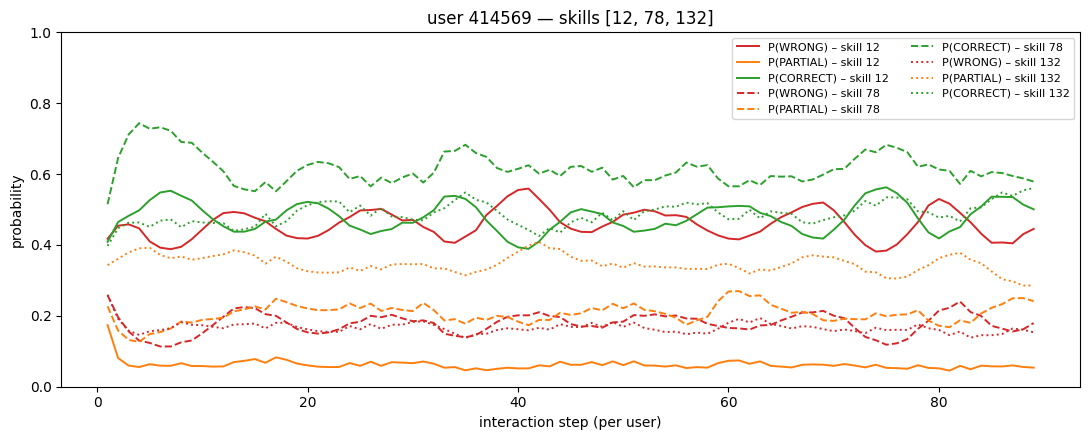

In [14]:
# Plot P(WRONG / PARTIAL / CORRECT) over time for one user across one or more skills.
# X-axis: that user's interaction index (timestep). Markers indicate the
# evaluation outcome whenever the user actually attempted that skill.

import matplotlib.pyplot as plt

USER_ID   = 414569            # change me
SKILL_IDS = [12, 78, 132]          # change me — list of factorized skill ids

# Per-user step index — row 0 has no prediction, so steps go 1..N-1.
user_rows = user_row_idx[USER_ID]
step_of   = pd.Series(np.arange(len(user_rows)), index=user_rows)

eval_color = {0: 'tab:red', 1: 'tab:orange', 2: 'tab:green'}
eval_label = {0: 'WRONG', 1: 'PARTIAL', 2: 'CORRECT'}
linestyles = ['-', '--', ':', '-.']
markers    = ['o', 's', '^', 'D']

attempts_user = X.iloc[user_rows].copy()
attempts_user['step'] = np.arange(len(attempts_user))

fig, ax = plt.subplots(figsize=(11, 4.5))
for k, skill_id in enumerate(SKILL_IDS):
    ls = linestyles[k % len(linestyles)]

    trace = (
        skill_probs[(skill_probs['user_id'] == USER_ID) &
                    (skill_probs['skill']   == skill_id)]
        .sort_values('row_idx')
        .reset_index(drop=True)
    )
    trace['step'] = trace['row_idx'].map(step_of)

    ax.plot(trace['step'], trace['p_wrong'],   lw=1.4, ls=ls, color='tab:red',
            label=f'P(WRONG) – skill {skill_id}')
    ax.plot(trace['step'], trace['p_partial'], lw=1.4, ls=ls, color='tab:orange',
            label=f'P(PARTIAL) – skill {skill_id}')
    ax.plot(trace['step'], trace['p_correct'], lw=1.4, ls=ls, color='tab:green',
            label=f'P(CORRECT) – skill {skill_id}')

    # Attempt markers for this skill — vertical band per skill so they don't overlap.
    sub = attempts_user[attempts_user['skill'] == skill_id]
    y0  = 0.02 + 0.10 * k
    for code, sub_c in sub.groupby('correct'):
        ax.scatter(sub_c['step'], np.full(len(sub_c), y0 + 0.025 * code),
                   color=eval_color[code], s=40,
                   edgecolor='black', linewidth=0.5,
                   marker=markers[k % len(markers)],
                   label=f'skill {skill_id} – {eval_label[code]}', zorder=3)

ax.set_xlabel('interaction step (per user)')
ax.set_ylabel('probability')
ax.set_ylim(0, 1)
ax.set_title(f'user {USER_ID} — skills {SKILL_IDS}')
ax.legend(loc='best', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

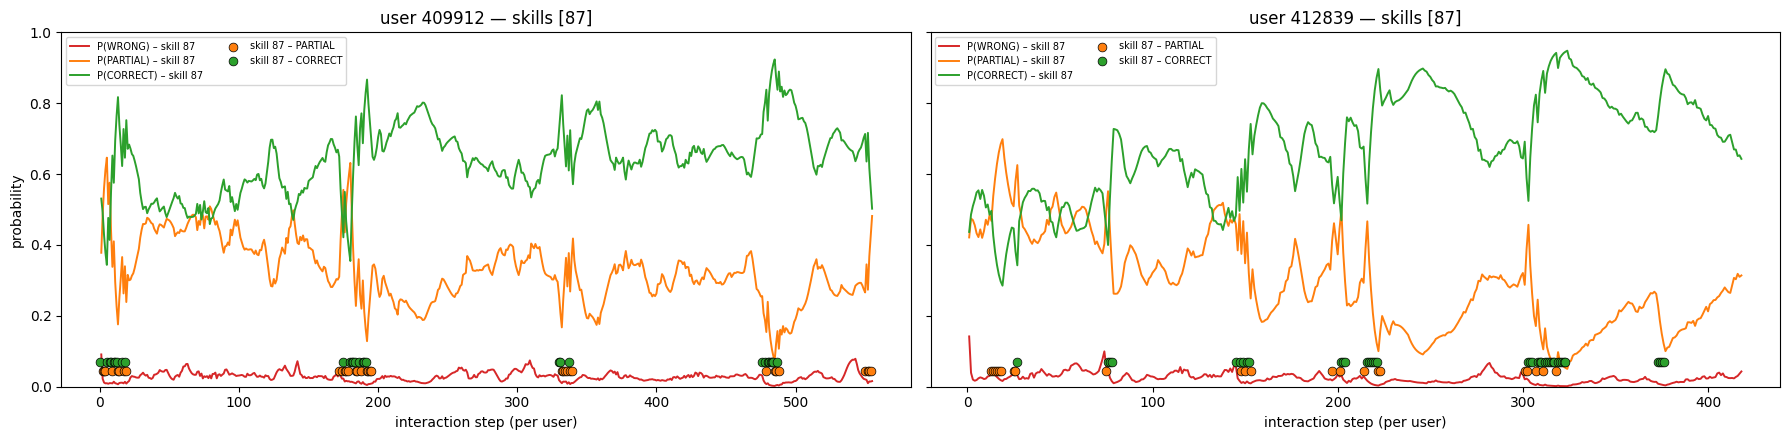

In [ ]:
# Side-by-side comparison: same SKILL_IDS, two different users.

USER_IDS  = [409912, 412839]   # left, right
SKILL_IDS = [87]           # change me

eval_color = {0: 'tab:red', 1: 'tab:orange', 2: 'tab:green'}
eval_label = {0: 'WRONG', 1: 'PARTIAL', 2: 'CORRECT'}
linestyles = ['-', '--', ':', '-.']
markers    = ['o', 's', '^', 'D']


def plot_user(ax, user_id, skill_ids):
    user_rows = user_row_idx[user_id]
    step_of   = pd.Series(np.arange(len(user_rows)), index=user_rows)
    attempts_user = X.iloc[user_rows].copy()
    attempts_user['step'] = np.arange(len(attempts_user))

    for k, skill_id in enumerate(skill_ids):
        ls = linestyles[k % len(linestyles)]
        trace = (
            skill_probs[(skill_probs['user_id'] == user_id) &
                        (skill_probs['skill']   == skill_id)]
            .sort_values('row_idx')
            .reset_index(drop=True)
        )
        trace['step'] = trace['row_idx'].map(step_of)

        ax.plot(trace['step'], trace['p_wrong'],   lw=1.4, ls=ls, color='tab:red',
                label=f'P(WRONG) – skill {skill_id}')
        ax.plot(trace['step'], trace['p_partial'], lw=1.4, ls=ls, color='tab:orange',
                label=f'P(PARTIAL) – skill {skill_id}')
        ax.plot(trace['step'], trace['p_correct'], lw=1.4, ls=ls, color='tab:green',
                label=f'P(CORRECT) – skill {skill_id}')

        sub = attempts_user[attempts_user['skill'] == skill_id]
        y0  = 0.02 + 0.10 * k
        for code, sub_c in sub.groupby('correct'):
            ax.scatter(sub_c['step'], np.full(len(sub_c), y0 + 0.025 * code),
                        color=eval_color[code], s=40,
                        edgecolor='black', linewidth=0.5,
                        marker=markers[k % len(markers)],
                        label=f'skill {skill_id} – {eval_label[code]}', zorder=3)

    ax.set_xlabel('interaction step (per user)')
    ax.set_ylim(0, 1)
    ax.set_title(f'user {user_id} — skills {skill_ids}')
    ax.legend(loc='best', fontsize=7, ncol=2)


fig, axes = plt.subplots(1, 2, figsize=(18, 4.5), sharey=True)
for ax, uid in zip(axes, USER_IDS):
    plot_user(ax, uid, SKILL_IDS)
axes[0].set_ylabel('probability')
plt.tight_layout()
plt.show()

In [16]:
# Build a per-skill summary DataFrame:
#   skill       : factorized skill id (column `skill` in X)
#   skill_name  : raw "topic_id_difficulty" code
#   topic_id    : underlying topic id
#   topic_name  : human-readable topic name from topics_translated
#   difficulty  : estimatedDifficulty band (-2 means missing)
#   n_attempts  : how many rows in X carry this skill
#
# Skill keys are produced in src/features.py as f"{topic_id}_{estimatedDifficulty}",
# so splitting on the last underscore recovers both fields.

counts = X.groupby(['skill', 'skill_name']).size().rename('n_attempts').reset_index()

split = counts['skill_name'].str.rsplit('_', n=1, expand=True)
counts['topic_id']   = split[0].astype(int)
counts['difficulty'] = split[1].astype(int)
counts['topic_name'] = counts['topic_id'].map(lookups['id_to_name'])

skill_info = (
    counts[['skill', 'skill_name', 'topic_id', 'topic_name',
            'difficulty', 'n_attempts']]
    .sort_values('n_attempts', ascending=False)
    .reset_index(drop=True)
)
print(f"{len(skill_info)} skills | total attempts: {skill_info['n_attempts'].sum()}")
skill_info.head(15)

157 skills | total attempts: 293465


,skill,skill_name,topic_id,topic_name,difficulty,n_attempts
0,87,951_2,951,Number sets,2,15147
1,89,952_1,952,Fractions - basic arithmetic operations,1,13429
2,99,958_1,958,Powers,1,10051
3,17,1007_2,1007,Function term,2,9803
4,136,978_2,978,Fraction terms,2,9355
5,86,951_1,951,Number sets,1,8485
6,135,978_1,978,Fraction terms,1,8436
7,19,1010_1,1010,Linear functions,1,8100
8,23,1018_1,1018,Quadratic functions,1,8089
9,90,952_2,952,Fractions - basic arithmetic operations,2,7625


In [17]:
# Find users where SKILL_ID makes up a large fraction of their interactions,
# but who have relatively few total attempts overall.
#
# Filters (tweak as needed):
#   - at least MIN_ON_SKILL attempts on this skill (so the trace isn't trivial)
#   - at most MAX_TOTAL total attempts across all skills
# Ranked by share = attempts_on_skill / total_attempts, descending.

MIN_ON_SKILL = 50
MAX_TOTAL    = 1000000
SKILL_ID     = 87   # change me — factorized skill id from X['skill']

per_user = (
    X.assign(is_skill=(X['skill'] == SKILL_ID))
     .groupby('user_id')
     .agg(total=('skill', 'size'), on_skill=('is_skill', 'sum'))
)
per_user['share'] = per_user['on_skill'] / per_user['total']

candidates = (
    per_user[(per_user['on_skill'] >= MIN_ON_SKILL) &
             (per_user['total']    <= MAX_TOTAL)]
    .sort_values(['share', 'on_skill'], ascending=[False, False])
    .head(15)
)
print(f"top candidates for skill {SKILL_ID} "
      f"(>= {MIN_ON_SKILL} attempts on skill, <= {MAX_TOTAL} total):")
candidates

top candidates for skill 87 (>= 50 attempts on skill, <= 1000000 total):


,total,on_skill,share
user_id,,,
430134,70,50,0.714286
412162,110,76,0.690909
410616,129,58,0.449612
393829,295,121,0.410169
414269,155,56,0.361290
413876,226,54,0.238938
412839,419,61,0.145585
409912,556,63,0.113309


In [29]:
# Topic-impact analysis: for a chosen source skill A, measure how answering A
# perturbs the model's belief about every other skill B. For every (user, t)
# where the user attempted A, take |P_after(correct on B) − P_before(correct on B)|
# for each target skill B, then aggregate per B with mean / std / 95% CI.
#
# - "Before" = skill_probs at the X position of the A attempt
#              (history excludes A — see alignment in the cell that builds skill_probs).
# - "After"  = skill_probs at the next X position for the same user
#              (history now includes the A attempt). A attempts that are the
#              user's last interaction are skipped.
# - Targets are ranked by mean |Δ|, descending. CIs use the t distribution.
#
# Caveat: deltas within a student aren't independent, so the CIs / p-values
# are slightly optimistic — fine for *ranking* topics by impact, less so for
# absolute significance claims. Permutation testing would be the next step.

from scipy import stats

SOURCE_SKILL = 23   # change me — source skill A (factorized id from X['skill'])

# Wide table: row_idx × skill → P(correct on skill at that step).
wide_pc = (
    skill_probs
    .pivot_table(index='row_idx', columns='skill', values='p_correct')
    .sort_index()
)

# For each X position, the next X position belonging to the same user
# (-1 if it's the user's last attempt).
next_pos_arr = np.full(len(X), -1, dtype=np.int64)
for uid, positions in user_row_idx.items():
    if len(positions) > 1:
        next_pos_arr[positions[:-1]] = positions[1:]

# Source events: rows where user answered SOURCE_SKILL, a "next" row exists,
# and both rows carry predictions (the very first row per user has none).
src_pos = np.flatnonzero(X['skill'].values == SOURCE_SKILL)
nxt     = next_pos_arr[src_pos]
keep    = nxt != -1
src_pos, nxt = src_pos[keep], nxt[keep]

valid = wide_pc.index
keep  = np.isin(src_pos, valid) & np.isin(nxt, valid)
src_pos, nxt = src_pos[keep], nxt[keep]

before = wide_pc.loc[src_pos].to_numpy()
after  = wide_pc.loc[nxt].to_numpy()
delta  = np.abs(after - before)                             # (n_obs, n_skills)

n_obs    = delta.shape[0]
mean_d   = delta.mean(axis=0)
std_d    = delta.std(axis=0, ddof=1)
sem      = std_d / np.sqrt(n_obs)
ci_half  = stats.t.ppf(0.975, df=n_obs - 1) * sem

impact = pd.DataFrame({
    'target_skill':   wide_pc.columns,
    'mean_abs_delta': mean_d,
    'std_abs_delta':  std_d,
    'ci_low':         mean_d - ci_half,
    'ci_high':        mean_d + ci_half,
    'n_obs':          n_obs,
})

impact = (
    impact
    .merge(skill_info[['skill', 'topic_id', 'topic_name', 'difficulty']],
           left_on='target_skill', right_on='skill', how='left')
    .drop(columns='skill')
    .sort_values('mean_abs_delta', ascending=False)
    .reset_index(drop=True)
)

src_meta = skill_info.loc[skill_info['skill'] == SOURCE_SKILL].iloc[0]
print(f"Source skill {SOURCE_SKILL}: {src_meta['topic_name']} "
      f"(diff {src_meta['difficulty']}) | {n_obs} answer events")
impact.head(20)


Source skill 23: Quadratic functions (diff 1) | 7780 answer events


,target_skill,mean_abs_delta,std_abs_delta,ci_low,ci_high,n_obs,topic_id,topic_name,difficulty
0,23,0.068989,0.045210,0.067984,0.069994,7780,1018,Quadratic functions,1
1,106,0.032028,0.021172,0.031557,0.032498,7780,963,Scientific notation,1
2,8,0.026101,0.020828,0.025638,0.026564,7780,1003,Root equations,1
3,96,0.025402,0.019971,0.024958,0.025846,7780,957,Fractions ↔ Decimal fractions,1
4,71,0.025269,0.022938,0.024759,0.025778,7780,1063,"General triangles, sine and cosine theorems",1
5,31,0.025258,0.017608,0.024867,0.025649,7780,1029,Translations of function graphs,2
6,39,0.024315,0.020157,0.023867,0.024762,7780,1035,Evidence by congruence,2
7,0,0.023454,0.017213,0.023071,0.023836,7780,1001,Convert formulas,1
8,16,0.023027,0.025649,0.022457,0.023597,7780,1007,Function term,1
9,92,0.022586,0.019350,0.022156,0.023016,7780,952,Fractions - basic arithmetic operations,4


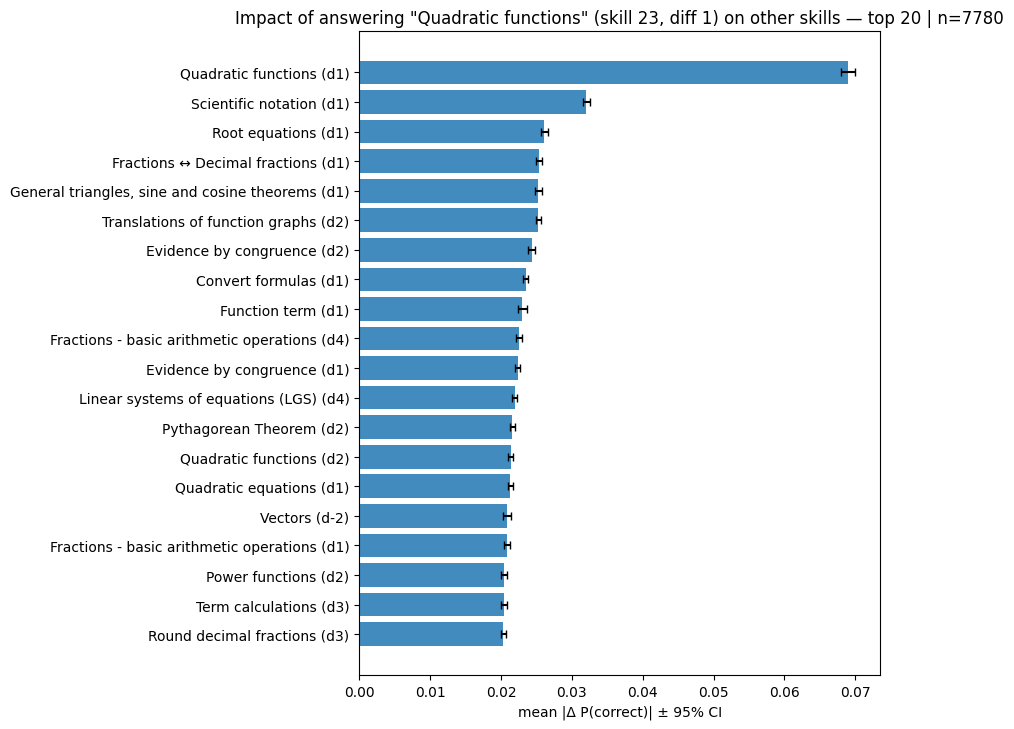

In [33]:
# Top-K most-affected target skills, with 95% CI error bars.

TOP_K = 20

top = impact.head(TOP_K).iloc[::-1]            # reverse so highest is at the top
labels = [f"{r.topic_name} (d{r.difficulty})" for r in top.itertuples()]
err    = np.vstack([top['mean_abs_delta'] - top['ci_low'],
                    top['ci_high']        - top['mean_abs_delta']])

fig, ax = plt.subplots(figsize=(9, 0.32 * TOP_K + 1))
ax.barh(labels, top['mean_abs_delta'], xerr=err,
        color='tab:blue', alpha=0.85, ecolor='black', capsize=3)
ax.set_xlabel('mean |Δ P(correct)| ± 95% CI')
ax.set_title(f'Impact of answering "{src_meta["topic_name"]}" '
             f'(skill {SOURCE_SKILL}, diff {src_meta["difficulty"]}) '
             f'on other skills — top {TOP_K} | n={n_obs}')
plt.tight_layout()
plt.show()


In [35]:
# All-pairs (source → target) impact: mean |Δ P(correct)| for every (A, B).
# Same construction as the single-source cell, but built in one vectorized pass:
# we form every (row, next_row) pair in X, take |Δ| per target skill, then
# group by source skill (= the skill answered at `row`).
#
# Self-interactions (A == B) are excluded from the ranking — answering a
# question on A obviously moves the model's belief about A.

# All (pos, next_pos) pairs that have predictions on both ends.
all_pos = np.arange(len(X))
nxt_all = next_pos_arr
keep    = nxt_all != -1
all_pos, nxt_all = all_pos[keep], nxt_all[keep]
keep    = np.isin(all_pos, valid) & np.isin(nxt_all, valid)
all_pos, nxt_all = all_pos[keep], nxt_all[keep]

source_skill = X['skill'].values[all_pos]
before_all   = wide_pc.loc[all_pos].to_numpy(dtype=np.float32)
after_all    = wide_pc.loc[nxt_all].to_numpy(dtype=np.float32)
delta_all    = np.abs(after_all - before_all)               # (n_events, n_skills)

deltas = pd.DataFrame(delta_all, columns=wide_pc.columns)
deltas['source'] = source_skill
g = deltas.groupby('source')

mean_mat = g.mean()
std_mat  = g.std()
n_src    = g.size()                                          # events per source

# Long form: one row per (source, target) cell; drop the diagonal.
# dropna=False keeps NaN std cells (e.g. sources with n=1) aligned with means.
mean_long = mean_mat.stack(dropna=False).rename('mean_abs_delta')
std_long  = std_mat.stack(dropna=False).rename('std_abs_delta')
long = pd.concat([mean_long, std_long], axis=1).reset_index()
long.columns = ['source', 'target', 'mean_abs_delta', 'std_abs_delta']
long['n_obs'] = long['source'].map(n_src).astype(int)
long = long[long['source'] != long['target']].copy()
long = long.dropna(subset=['mean_abs_delta'])

sem    = long['std_abs_delta'] / np.sqrt(long['n_obs'])
t_crit = stats.t.ppf(0.975, df=long['n_obs'] - 1)
long['ci_low']  = long['mean_abs_delta'] - t_crit * sem
long['ci_high'] = long['mean_abs_delta'] + t_crit * sem

name_of = skill_info.set_index('skill')[['topic_name', 'difficulty']]
long['source_name'] = long['source'].map(name_of['topic_name'])
long['source_diff'] = long['source'].map(name_of['difficulty'])
long['target_name'] = long['target'].map(name_of['topic_name'])
long['target_diff'] = long['target'].map(name_of['difficulty'])

top10 = (
    long.sort_values('mean_abs_delta', ascending=False)
        .head(10)
        .reset_index(drop=True)
)
print("Top 10 (source → target) interactions by mean |Δ P(correct)|:")
top10[['source', 'source_name', 'source_diff',
       'target', 'target_name', 'target_diff',
       'mean_abs_delta', 'std_abs_delta', 'ci_low', 'ci_high', 'n_obs']]


Top 10 (source → target) interactions by mean |Δ P(correct)|:


/var/folders/ds/bfzx964511l9xh7hkftcw1y40000gn/T/ipykernel_19196/4083978067.py:32: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_long = mean_mat.stack(dropna=False).rename('mean_abs_delta')
/var/folders/ds/bfzx964511l9xh7hkftcw1y40000gn/T/ipykernel_19196/4083978067.py:33: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_long  = std_mat.stack(dropna=False).rename('std_abs_delta')


,source,source_name,source_diff,target,target_name,target_diff,mean_abs_delta,std_abs_delta,ci_low,ci_high,n_obs
0,54,Beam sets,4,53,Beam sets,3,0.087823,0.040366,0.082775,0.092872,248
1,18,Linear functions,-2,19,Linear functions,1,0.083218,0.045649,0.074427,0.092010,106
2,126,Factorize,-2,54,Beam sets,4,0.080380,0.061386,0.039141,0.121620,11
3,126,Factorize,-2,47,Vectors,-2,0.076315,0.058012,0.037343,0.115288,11
4,147,Linear systems of equations (LGS),-2,148,Linear systems of equations (LGS),1,0.075972,0.042029,0.068103,0.083842,112
5,85,Number sets,-2,16,Function term,1,0.067910,0.021876,0.047678,0.088141,7
6,119,Distributive law,-2,71,"General triangles, sine and cosine theorems",1,0.067746,NaN,NaN,NaN,1
7,54,Beam sets,4,52,Beam sets,2,0.067699,0.038171,0.062925,0.072473,248
8,138,Fraction terms,4,137,Fraction terms,3,0.067630,0.028055,0.064601,0.070659,332
9,73,"General triangles, sine and cosine theorems",3,71,"General triangles, sine and cosine theorems",1,0.067184,0.044035,0.061120,0.073248,205


In [42]:
# Pick a focus set of topics: the top-N most-represented topics, plus their
# topic-tree siblings re-added (so that ranking by raw attempt count doesn't
# fragment a sibling group across the cutoff).
#
# Output is one row per topic_id (difficulty bands aggregated):
#   topic_id, topic_name, n_attempts (summed across difficulties),
#   n_difficulty_bands (how many skill rows fed into the sum),
#   in_top_n (True for the original top-N, False for added siblings).
# "Siblings" = other topic_ids sharing the same parent in the topic tree
#              (uses lookups['child_to_parent']).

def top_topics_with_siblings(
    skill_info: pd.DataFrame,
    child_to_parent: dict,
    top_n: int = 15,
) -> pd.DataFrame:
    topic_attempts = (
        skill_info.groupby('topic_id', as_index=False)
                  .agg(topic_name=('topic_name', 'first'),
                       n_attempts=('n_attempts', 'sum'),
                       n_difficulty_bands=('skill', 'nunique'))
                  .sort_values('n_attempts', ascending=False)
    )
    top_topics = topic_attempts.head(top_n)['topic_id'].tolist()

    # Invert child→parent once so sibling lookup is O(1) per topic.
    parent_to_children = collections.defaultdict(list)
    for child, parent in child_to_parent.items():
        parent_to_children[parent].append(child)

    expanded = set()
    for tid in top_topics:
        expanded.add(tid)
        parent = child_to_parent.get(tid)
        if parent is not None:
            expanded.update(parent_to_children.get(parent, []))

    return (
        topic_attempts[topic_attempts['topic_id'].isin(expanded)]
        .assign(in_top_n=lambda d: d['topic_id'].isin(top_topics))
        .sort_values(['n_attempts', 'topic_id'], ascending=[False, True])
        .reset_index(drop=True)
    )


focus_topics = top_topics_with_siblings(skill_info, lookups['child_to_parent'], top_n=10)
print(f"{len(focus_topics)} topics "
      f"(top 15 + siblings, from {skill_info['topic_id'].nunique()} total)")
focus_topics


30 topics (top 15 + siblings, from 43 total)


,topic_id,topic_name,n_attempts,n_difficulty_bands,in_top_n
0,952,Fractions - basic arithmetic operations,27762,4,True
1,951,Number sets,26301,4,True
2,978,Fraction terms,21499,5,True
3,1018,Quadratic functions,20137,3,True
4,958,Powers,19245,4,True
5,1010,Linear functions,13693,5,True
6,1007,Function term,12606,2,True
7,972,Binomial formulas,11767,3,True
8,987,Linear equations,11385,5,True
9,973,Factorize,10491,4,True


In [45]:
# Top 15 topics on their own (no siblings added). For each one, count how many
# of its topic-tree siblings *also* appear in the top 15. Print the total
# attempts contributed by the 15 topics combined.

topic_attempts = (
    skill_info.groupby('topic_id', as_index=False)
              .agg(topic_name=('topic_name', 'first'),
                   n_attempts=('n_attempts', 'sum'))
              .sort_values('n_attempts', ascending=False)
              .reset_index(drop=True)
)

top15 = topic_attempts.head(17).copy()
top15_ids = set(top15['topic_id'])

child_to_parent  = lookups['child_to_parent']
parent_to_children = collections.defaultdict(list)
for child, parent in child_to_parent.items():
    parent_to_children[parent].append(child)

def n_siblings_in_top15(tid: int) -> int:
    parent = child_to_parent.get(tid)
    if parent is None:
        return 0
    return sum(1 for s in parent_to_children[parent]
               if s != tid and s in top15_ids)

top15['siblings_in_top15'] = top15['topic_id'].map(n_siblings_in_top15)

total_attempts = int(top15['n_attempts'].sum())
print(f"Total attempts from all 15 top topics: {total_attempts:,} "
      f"({total_attempts / skill_info['n_attempts'].sum():.1%} of all attempts)")
top15


Total attempts from all 15 top topics: 225,893 (77.0% of all attempts)


,topic_id,topic_name,n_attempts,siblings_in_top15
0,952,Fractions - basic arithmetic operations,27762,4
1,951,Number sets,26301,4
2,978,Fraction terms,21499,3
3,1018,Quadratic functions,20137,2
4,958,Powers,19245,4
5,1010,Linear functions,13693,2
6,1007,Function term,12606,2
7,972,Binomial formulas,11767,3
8,987,Linear equations,11385,2
9,973,Factorize,10491,3


In [46]:
# Topic-level interactions, restricted to the 15 top topics on both sides.
# We re-aggregate `delta_all` (the per-event × per-skill |Δ P(correct)| matrix
# built earlier) up to topic level by averaging skill columns within each
# topic_id, so each row is one (event, target_topic) and each event is
# tagged with its source_topic.
#
# For each (A, B) pair (A != B) we report mean / std / 95% CI of |Δ| and the
# tree relationship between A and B:
#   - sibling      : same parent
#   - parent→child : B is a child of A
#   - child→parent : A is a child of B
#   - other        : none of the above (e.g. cousins, unrelated)

skill_to_topic = skill_info.set_index('skill')['topic_id']
top15_ids = top15['topic_id'].values

# Filter events to those whose source topic is in the top 15.
src_topic_per_event = pd.Series(source_skill).map(skill_to_topic).to_numpy()
src_mask = np.isin(src_topic_per_event, top15_ids)

# Filter target skill columns to those whose topic is in the top 15.
skill_cols = np.asarray(wide_pc.columns)
col_topic  = pd.Series(skill_cols).map(skill_to_topic).to_numpy()
col_mask   = np.isin(col_topic, top15_ids)

delta_sub      = delta_all[src_mask][:, col_mask]
sub_col_topics = col_topic[col_mask]
src_topic_sub  = src_topic_per_event[src_mask]

# For each target topic, average across its difficulty-band skill columns.
delta_topic = np.zeros((delta_sub.shape[0], len(top15_ids)), dtype=np.float32)
for j, tid in enumerate(top15_ids):
    cols = sub_col_topics == tid
    delta_topic[:, j] = delta_sub[:, cols].mean(axis=1)

df_t = pd.DataFrame(delta_topic, columns=top15_ids)
df_t['source_topic'] = src_topic_sub
gt = df_t.groupby('source_topic')

mean_t = gt.mean()
std_t  = gt.std()
n_t    = gt.size()

mean_long_t = mean_t.stack(dropna=False).rename('mean_abs_delta')
std_long_t  = std_t.stack(dropna=False).rename('std_abs_delta')
long_t = pd.concat([mean_long_t, std_long_t], axis=1).reset_index()
long_t.columns = ['source_topic', 'target_topic', 'mean_abs_delta', 'std_abs_delta']
long_t['n_obs'] = long_t['source_topic'].map(n_t).astype(int)
long_t = long_t[long_t['source_topic'] != long_t['target_topic']].copy()
long_t = long_t.dropna(subset=['mean_abs_delta'])

sem    = long_t['std_abs_delta'] / np.sqrt(long_t['n_obs'])
t_crit = stats.t.ppf(0.975, df=long_t['n_obs'] - 1)
long_t['ci_low']  = long_t['mean_abs_delta'] - t_crit * sem
long_t['ci_high'] = long_t['mean_abs_delta'] + t_crit * sem

# Tree-relationship label for each (A, B).
def _relation(a, b):
    pa, pb = child_to_parent.get(a), child_to_parent.get(b)
    if pb == a:
        return 'parent→child'
    if pa == b:
        return 'child→parent'
    if pa is not None and pa == pb:
        return 'sibling'
    return 'other'

long_t['relation'] = [
    _relation(a, b) for a, b in zip(long_t['source_topic'], long_t['target_topic'])
]

topic_name = topic_attempts.set_index('topic_id')['topic_name']
long_t['source_name'] = long_t['source_topic'].map(topic_name)
long_t['target_name'] = long_t['target_topic'].map(topic_name)

top20_t = (
    long_t.sort_values('mean_abs_delta', ascending=False)
          .head(20)
          .reset_index(drop=True)
)
print("Top 20 topic→topic interactions among the 15 most-represented topics:")
top20_t[['source_topic', 'source_name',
         'target_topic', 'target_name',
         'relation',
         'mean_abs_delta', 'std_abs_delta', 'ci_low', 'ci_high', 'n_obs']]


Top 20 topic→topic interactions among the 15 most-represented topics:


/var/folders/ds/bfzx964511l9xh7hkftcw1y40000gn/T/ipykernel_19196/2097791072.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_long_t = mean_t.stack(dropna=False).rename('mean_abs_delta')
/var/folders/ds/bfzx964511l9xh7hkftcw1y40000gn/T/ipykernel_19196/2097791072.py:45: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_long_t  = std_t.stack(dropna=False).rename('std_abs_delta')


,source_topic,source_name,target_topic,target_name,relation,mean_abs_delta,std_abs_delta,ci_low,ci_high,n_obs
0,951,Number sets,1041,Vectors,other,0.026365,0.026110,0.026033,0.026698,23700
1,956,Fractions - mixed tasks,1007,Function term,other,0.026008,0.022528,0.025433,0.026583,5891
2,951,Number sets,1007,Function term,other,0.025396,0.027017,0.025052,0.025740,23700
3,964,Roots,1007,Function term,other,0.024559,0.017993,0.024120,0.024997,6460
4,987,Linear equations,1007,Function term,other,0.024449,0.017416,0.024119,0.024779,10699
5,958,Powers,1007,Function term,other,0.023890,0.019305,0.023608,0.024172,18004
6,1010,Linear functions,1007,Function term,sibling,0.023462,0.019955,0.023119,0.023806,12968
7,951,Number sets,973,Factorize,other,0.023323,0.021584,0.023048,0.023597,23700
8,973,Factorize,1007,Function term,other,0.022842,0.022460,0.022396,0.023288,9758
9,952,Fractions - basic arithmetic operations,1007,Function term,other,0.022583,0.019728,0.022345,0.022822,26351


In [47]:
# Skill-level interactions (topic_id × difficulty), restricted to skills whose
# topic_id is in the top 15. Reuses the `long` table built in the all-pairs cell
# (which already excludes the i→i diagonal at skill granularity).
#
# `relation` is computed on the underlying topic ids:
#   - same-topic   : different difficulty bands of the same topic_id
#   - sibling      : different topics with the same parent
#   - parent→child : target's topic is a child of source's topic
#   - child→parent : source's topic is a child of target's topic
#   - other        : none of the above

top15_skills = set(skill_info.loc[skill_info['topic_id'].isin(top15_ids), 'skill'])

long_s = long[
    long['source'].isin(top15_skills) & long['target'].isin(top15_skills)
].copy()

skill_meta = skill_info.set_index('skill')[['topic_id', 'topic_name', 'difficulty']]
long_s['source_topic'] = long_s['source'].map(skill_meta['topic_id'])
long_s['source_diff']  = long_s['source'].map(skill_meta['difficulty'])
long_s['source_name']  = long_s['source'].map(skill_meta['topic_name'])
long_s['target_topic'] = long_s['target'].map(skill_meta['topic_id'])
long_s['target_diff']  = long_s['target'].map(skill_meta['difficulty'])
long_s['target_name']  = long_s['target'].map(skill_meta['topic_name'])

def _skill_relation(ta, tb):
    if ta == tb:
        return 'same-topic'
    pa, pb = child_to_parent.get(ta), child_to_parent.get(tb)
    if pb == ta:
        return 'parent→child'
    if pa == tb:
        return 'child→parent'
    if pa is not None and pa == pb:
        return 'sibling'
    return 'other'

long_s['relation'] = [
    _skill_relation(a, b) for a, b in zip(long_s['source_topic'], long_s['target_topic'])
]

top20_s = (
    long_s.sort_values('mean_abs_delta', ascending=False)
          .head(20)
          .reset_index(drop=True)
)
print("Top 20 skill→skill interactions among skills of the 15 most-represented topics:")
top20_s[['source', 'source_name', 'source_diff',
         'target', 'target_name', 'target_diff',
         'relation',
         'mean_abs_delta', 'std_abs_delta', 'ci_low', 'ci_high', 'n_obs']]


Top 20 skill→skill interactions among skills of the 15 most-represented topics:


,source,source_name,source_diff,target,target_name,target_diff,relation,mean_abs_delta,std_abs_delta,ci_low,ci_high,n_obs
0,54,Beam sets,4,53,Beam sets,3,same-topic,0.087823,0.040366,0.082775,0.092872,248
1,18,Linear functions,-2,19,Linear functions,1,same-topic,0.083218,0.045649,0.074427,0.092010,106
2,126,Factorize,-2,54,Beam sets,4,other,0.080380,0.061386,0.039141,0.121620,11
3,126,Factorize,-2,47,Vectors,-2,other,0.076315,0.058012,0.037343,0.115288,11
4,147,Linear systems of equations (LGS),-2,148,Linear systems of equations (LGS),1,same-topic,0.075972,0.042029,0.068103,0.083842,112
5,85,Number sets,-2,16,Function term,1,other,0.067910,0.021876,0.047678,0.088141,7
6,54,Beam sets,4,52,Beam sets,2,same-topic,0.067699,0.038171,0.062925,0.072473,248
7,138,Fraction terms,4,137,Fraction terms,3,same-topic,0.067630,0.028055,0.064601,0.070659,332
8,88,Number sets,3,87,Number sets,2,same-topic,0.064557,0.030059,0.063399,0.065715,2591
9,111,Roots,2,110,Roots,1,same-topic,0.062970,0.048829,0.060673,0.065267,1738


In [51]:
long_s[long_s['relation'] == 'sibling'].sort_values('mean_abs_delta', ascending=False).head(20)

,source,target,mean_abs_delta,std_abs_delta,n_obs,ci_low,ci_high,source_name,source_diff,target_name,target_diff,source_topic,target_topic,relation
13665,88,93,0.042499,0.053280,2591,0.040447,0.044552,Number sets,3,Fractions - mixed tasks,1,951,956,sibling
13353,86,93,0.041965,0.050974,6930,0.040764,0.043165,Number sets,1,Fractions - mixed tasks,1,951,956,sibling
13349,86,89,0.039456,0.036838,6930,0.038588,0.040323,Number sets,1,Fractions - basic arithmetic operations,1,951,952,sibling
23542,152,142,0.038780,NaN,1,NaN,NaN,Quadratic equations,-2,Linear equations,-2,997,987,sibling
19638,126,138,0.038174,0.025910,11,0.020768,0.055581,Factorize,-2,Fraction terms,4,973,978,sibling
19633,126,133,0.037502,0.019148,11,0.024638,0.050366,Factorize,-2,Power laws,4,973,974,sibling
23551,152,151,0.036202,NaN,1,NaN,NaN,Quadratic equations,-2,Linear systems of equations (LGS),4,997,992,sibling
2824,19,16,0.036133,0.028913,7573,0.035482,0.036784,Linear functions,1,Function term,1,1010,1007,sibling
2668,18,16,0.035106,0.024416,106,0.030404,0.039808,Linear functions,-2,Function term,1,1010,1007,sibling
13193,85,89,0.034845,0.027382,7,0.009521,0.060169,Number sets,-2,Fractions - basic arithmetic operations,1,951,952,sibling
